# Customer Churn Prediction

Customer churn refers to when customers stop using a company’s service.  
This project aims to predict churn using customer data.  
By analyzing demographic and service usage patterns, businesses can identify at-risk customers and take preventive action.



## Data Collection

We use the Telco Customer Churn dataset.  
It contains customer demographics, service details, and whether the customer churned.


In [1]:
import pandas as pd
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,MonthlyCharges,Churn
0,1,Female,0,Yes,No,12,Yes,Fiber optic,Month-to-month,70,Yes
1,2,Male,1,No,No,24,Yes,DSL,One year,45,No
2,3,Female,0,Yes,Yes,5,No,DSL,Month-to-month,30,Yes
3,4,Male,0,No,No,36,Yes,Fiber optic,Two year,80,No
4,5,Female,1,Yes,No,10,Yes,DSL,Month-to-month,55,Yes


## Data Cleaning

Data often contains categorical variables (like gender, contract type).  
We convert them into numeric values using dummy encoding.  
We also separate features (X) from the target variable (y).


In [2]:
df = pd.get_dummies(df, drop_first=True)
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]


## Modeling

We train a Logistic Regression model.  
This algorithm is suitable for binary classification problems like churn (Yes/No).


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.00      0.00      0.00         1
        True       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\Antonette\.conda\envs\EPYTHON\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Antonette\.conda\envs\EPYTHON\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Antonette\.conda\envs\EPYTHON\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

## Visualization

We visualize churn distribution to understand how balanced the dataset is.


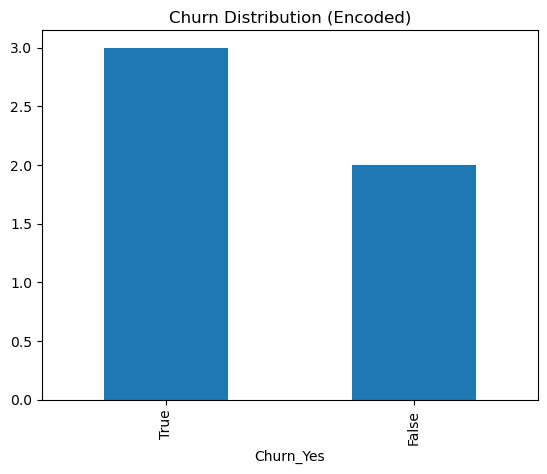

In [4]:
import matplotlib.pyplot as plt

df['Churn_Yes'].value_counts().plot(kind='bar')
plt.title("Churn Distribution (Encoded)")
plt.show()


## Conclusion

The model provides insights into which customers are likely to churn.  
Businesses can use these predictions to design retention strategies, such as loyalty programs or targeted offers.
